<a href="https://colab.research.google.com/github/rajnishpal7355200-sudo/Amazon_Prime_Video_EDA73793/blob/main/Amazon_Prime_Video_EDA_Rubric_Ready_Final_with_Summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Prime Video — Exploratory Data Analysis (EDA)

## Project Flow

**Project Statement & Data Understanding → Data Cleaning → Data Analysis → Visualizations → Insights → Business Recommendations**

### Business Objective
Analyze Amazon Prime Video titles and credits to identify content mix, genre patterns, production-country distribution, release trends, ratings/popularity relationships, and actor/director participation.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

> **Note:** This notebook intentionally uses only the libraries listed above for analysis and visualization. No Plotly or other visualization library is used.

## Project Information

**Project Name:** Amazon Prime Video — Exploratory Data Analysis (EDA)

**Project Type:** EDA

**Team Members:** Rajnish Pal (Individual Project)

## Project Summary

This project focuses on performing Exploratory Data Analysis (EDA) on an Amazon Prime Video dataset to understand the platform’s content library and identify meaningful patterns, trends, and insights. The dataset contains information about shows and movies available on Amazon Prime Video in the United States. The main purpose of this analysis is to explore the characteristics of the content library and provide data-driven insights that can help understand content distribution, ratings, genres, release years, countries, and other important attributes.

The project begins with understanding the structure and characteristics of the dataset. The dataset is examined using basic exploratory techniques such as viewing the first and last records, checking the shape of the dataset, understanding column data types, generating summary statistics, and creating a data dictionary. These steps help identify the important variables and understand the overall quality and structure of the available data.

Data cleaning and preprocessing are important parts of this project. Missing or null values are identified and handled appropriately wherever required. Columns containing multiple values, such as genres, directors, cast members, and countries, are processed to make them suitable for analysis. Reusable functions are also used in the analysis to improve code modularity and maintainability. Outliers are examined using statistical techniques such as the Interquartile Range (IQR) method where applicable.

The analysis explores several important questions related to Amazon Prime Video’s content. It examines the distribution of different show types, such as movies and TV shows, and analyzes content based on release years. Genre information is explored to identify popular and frequently occurring categories. The analysis also investigates IMDb scores and rating categories to understand the quality distribution of the available content. Additional analysis is performed on countries, directors, cast members, and other relevant attributes available in the dataset.

Data visualization is a major component of this project. Different visualization techniques are used to communicate findings clearly, including count plots, bar charts, histograms, box plots, pie charts, and other suitable charts. More than 20 visualizations are included in the notebook, with 25 visualizations used to present different aspects of the dataset. Each visualization is accompanied by an explanation of the key insight or trend observed from the data.

The project uses Python along with important data analysis and visualization libraries, including Pandas, NumPy, Matplotlib, and Seaborn. Google Colab is used as the development environment for creating and executing the notebook. The analysis also includes correlation and trend exploration to identify relationships between relevant numerical variables and to support meaningful conclusions.

Overall, this EDA project provides a structured understanding of the Amazon Prime Video content library. The findings can help identify content trends, understand audience-oriented categories, compare content characteristics, and observe how the platform’s library has developed over time. The project demonstrates the complete EDA workflow, including data understanding, cleaning, preprocessing, statistical analysis, visualization, interpretation, and conclusion. It also demonstrates the practical use of Python-based data analysis techniques to convert a raw dataset into useful and understandable business insights. The results can support content planning, catalog evaluation, and future analysis by providing a clear evidence-based view of the available titles and their characteristics.

## 1. Project Statement & Business Questions

The dataset contains Amazon Prime Video titles available in the United States. The analysis focuses on the following questions:

1. Are **Movies** more dominant than **TV Shows**?
2. Which **genres** are most common?
3. How has the number of titles changed over **release years**?
4. Which **production countries** contribute the most titles?
5. How are **IMDb ratings** distributed?
6. Is there a relationship between **IMDb ratings and IMDb votes**?
7. How closely do **IMDb and TMDB scores** move together?
8. Which **actors and directors** appear across the largest number of unique titles?
9. What business insights can be derived for content strategists, marketing teams, and investors?

## 2. Dataset Understanding

There are two CSV files:

### `titles.csv`
Contains title-level information such as:
`id`, `title`, `type`, `description`, `release_year`, `age_certification`, `runtime`, `genres`, `production_countries`, `seasons`, `imdb_id`, `imdb_score`, `imdb_votes`, `tmdb_popularity`, and `tmdb_score`.

### `credits.csv`
Contains person-level information linked to titles:
`person_id`, `id`, `name`, `character`, and `role`.

Because one title can have many credit rows, **title counts after joining credits must use `nunique()` on `id`**.

In [1]:
# 3. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ast
import zipfile
from pathlib import Path
try:
    from google.colab import files
except ImportError:
    files = None

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# 3. Load the supplied datasets


titles = pd.read_csv('titles.csv.zip')
credits = pd.read_csv('credits.csv.zip')


print("Titles shape :", titles.shape)
print("Credits shape:", credits.shape)

Titles shape : (9871, 15)
Credits shape: (124235, 5)


In [3]:
# 6. Initial inspection
print("Titles columns:")
print(titles.columns.tolist())

print("\nCredits columns:")
print(credits.columns.tolist())

display(titles.head())
display(credits.head())

Titles columns:
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

Credits columns:
['person_id', 'id', 'name', 'character', 'role']


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [4]:
# 7. Data types and missing values
print("Titles information:")
titles.info()

print("\nMissing values in titles:")
display(titles.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nMissing values in credits:")
display(credits.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

Titles information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes

,missing_count
seasons,8514
age_certification,6487
tmdb_score,2082
imdb_votes,1031
imdb_score,1021
imdb_id,667
tmdb_popularity,547
description,119
runtime,0
title,0



Missing values in credits:


,missing_count
character,16287
person_id,0
id,0
name,0
role,0


## 3A. Required Exploration: Head, Tail, Summary and Data Dictionary

The EDA begins with basic exploration before cleaning or visualization. This includes the first and last records, structure, summary statistics, and a concise data dictionary.

### Data dictionary

**titles.csv:** `id` (title ID), `title` (title name), `type` (MOVIE/SHOW), `description` (synopsis), `release_year` (release year), `age_certification` (content certification), `runtime` (minutes), `genres` (genre list), `production_countries` (production-country list), `seasons` (TV-show seasons), `imdb_id` (IMDb title ID), `imdb_score` (IMDb rating), `imdb_votes` (IMDb vote count), `tmdb_popularity` (TMDB popularity), `tmdb_score` (TMDB rating).

**credits.csv:** `person_id` (person ID), `id` (title ID), `name` (person name), `character` (character name), `role` (ACTOR/DIRECTOR).


In [5]:
# Required exploration: head, tail, shape, data types and summary
print("FIRST 5 TITLE RECORDS")
display(titles.head())

print("LAST 5 TITLE RECORDS")
display(titles.tail())

print("TITLE DATASET SHAPE:", titles.shape)
print("CREDITS DATASET SHAPE:", credits.shape)

print("\nTITLE DATA TYPES")
display(titles.dtypes.to_frame("dtype"))

print("\nNUMERIC SUMMARY")
numeric_preview = titles.select_dtypes(include=np.number)
display(numeric_preview.describe().T.round(2))


FIRST 5 TITLE RECORDS


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


LAST 5 TITLE RECORDS


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN
9870,ts275838,Waking Up Eighty,SHOW,"Kara Stewart, 16, is fed up with just about ev...",2021,NaN,10,['drama'],[],1.0,tt13542552,NaN,NaN,NaN,NaN


TITLE DATASET SHAPE: (9871, 15)
CREDITS DATASET SHAPE: (124235, 5)

TITLE DATA TYPES


,dtype
id,object
title,object
type,object
description,object
release_year,int64
age_certification,object
runtime,int64
genres,object
production_countries,object
seasons,float64



NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max
release_year,9871.0,2001.33,25.81,1912.0,1995.50,2014.00,2018.00,2022.00
runtime,9871.0,85.97,33.51,1.0,65.00,89.00,102.00,549.00
seasons,1357.0,2.79,4.15,1.0,1.00,1.00,3.00,51.00
imdb_score,8850.0,5.98,1.34,1.1,5.10,6.10,6.90,9.90
imdb_votes,8840.0,8533.61,45920.15,5.0,117.00,462.50,2236.25,1133692.00
tmdb_popularity,9324.0,6.91,30.00,0.0,1.23,2.54,5.63,1437.91
tmdb_score,7789.0,5.98,1.52,0.8,5.10,6.00,6.90,10.00


## 3B. Missing Values and Outlier Strategy

### Missing-value logic

Missing values are handled according to the meaning of each field rather than deleting rows blindly:

- `age_certification`: missing values are labelled **Not Rated**.
- `seasons`: missing values are expected for Movies and are represented as **0** for analysis.
- Numeric rating/popularity fields are kept as missing when the source does not provide a value; calculations use appropriate `dropna()` or Pandas aggregation behavior.
- `genres` and `production_countries` missing values are converted to empty lists before exploding.

### Outlier logic

IMDb votes and TMDB popularity are naturally right-skewed, so very large values can be genuine popular-title observations rather than data errors. Instead of automatically deleting them, the notebook identifies extreme observations with the IQR rule and uses robust summaries/appropriate plots. This preserves meaningful business information while avoiding distortion of ordinary comparisons.


In [6]:
# Outlier diagnostics using the IQR rule
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        s = pd.to_numeric(data[col], errors="coerce").dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((s < lower) | (s > upper)).sum()
        rows.append({
            "column": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(count)
        })
    return pd.DataFrame(rows).round(2)

outlier_columns = ["runtime", "imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score"]
outlier_report = iqr_outlier_summary(titles, outlier_columns)
display(outlier_report)
print("Outliers are reviewed rather than removed automatically because extreme popularity/vote values can be legitimate observations.")


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,runtime,65.00,102.00,37.00,9.50,157.50,275
1,imdb_score,5.10,6.90,1.80,2.40,9.60,65
2,imdb_votes,117.00,2236.25,2119.25,-3061.88,5415.12,1354
3,tmdb_popularity,1.23,5.63,4.40,-5.37,12.24,917
4,tmdb_score,5.10,6.90,1.80,2.40,9.60,324


Outliers are reviewed rather than removed automatically because extreme popularity/vote values can be legitimate observations.


## 3. Data Cleaning & Preprocessing

Cleaning decisions:

- Remove exact duplicate rows.
- Keep one record per title `id` in the title-level dataset.
- Convert numeric columns safely.
- Strip whitespace from text fields.
- Convert `genres` and `production_countries` from list-like strings into Python lists.
- Missing `seasons` is expected for Movies, so it is represented as `0` for analysis.
- Missing age certification is labelled `Not Rated`.

In [7]:
# 8. Create working copies and remove duplicates
df = titles.copy()
credits_df = credits.copy()

print("Duplicate title rows before cleaning:", df.duplicated().sum())
print("Duplicate credit rows before cleaning:", credits_df.duplicated().sum())

df = df.drop_duplicates()
credits_df = credits_df.drop_duplicates()

# One title-level record per title ID
df = df.drop_duplicates(subset="id", keep="first")

print("Cleaned titles shape :", df.shape)
print("Cleaned credits shape:", credits_df.shape)

Duplicate title rows before cleaning: 3
Duplicate credit rows before cleaning: 56
Cleaned titles shape : (9868, 15)
Cleaned credits shape: (124179, 5)


In [8]:
# 9. Clean text and numeric columns
text_cols = ["title", "description", "age_certification", "imdb_id"]

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

credits_df["name"] = credits_df["name"].astype("string").str.strip()
credits_df["character"] = credits_df["character"].astype("string").str.strip()
credits_df["role"] = credits_df["role"].astype("string").str.strip().str.upper()

numeric_cols = [
    "release_year", "runtime", "seasons", "imdb_score",
    "imdb_votes", "tmdb_popularity", "tmdb_score"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_cols].dtypes)

release_year         int64
runtime              int64
seasons            float64
imdb_score         float64
imdb_votes         float64
tmdb_popularity    float64
tmdb_score         float64
dtype: object


In [9]:
# 10. Convert list-like columns
def parse_list(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        result = ast.literal_eval(value)
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

df["genres"] = df["genres"].apply(parse_list)
df["production_countries"] = df["production_countries"].apply(parse_list)

print("Sample parsed genres:")
display(df[["title", "genres"]].head())

print("Sample parsed production countries:")
display(df[["title", "production_countries"]].head())

Sample parsed genres:


,title,genres
0,The Three Stooges,"[comedy, family, animation, action, fantasy, h..."
1,The General,"[action, drama, war, western, comedy, european]"
2,The Best Years of Our Lives,"[romance, war, drama]"
3,His Girl Friday,"[comedy, drama, romance]"
4,In a Lonely Place,"[thriller, drama, romance]"


Sample parsed production countries:


,title,production_countries
0,The Three Stooges,[US]
1,The General,[US]
2,The Best Years of Our Lives,[US]
3,His Girl Friday,[US]
4,In a Lonely Place,[US]


In [10]:
# 11. Create analysis features
df["show_type"] = df["type"].map({
    "MOVIE": "Movie",
    "SHOW": "TV Show"
}).fillna(df["type"])

df["age_certification"] = df["age_certification"].fillna("Not Rated")
df["seasons"] = df["seasons"].fillna(0)

df["genre_count"] = df["genres"].apply(len)
df["country_count"] = df["production_countries"].apply(len)

df["release_decade"] = (df["release_year"] // 10) * 10

df["rating_category"] = pd.cut(
    df["imdb_score"],
    bins=[0, 5, 7, 8, 9, 10],
    labels=["Poor", "Average", "Good", "Very Good", "Excellent"],
    include_lowest=True
)

print("Feature engineering completed.")
display(df[[
    "title", "show_type", "release_year", "runtime",
    "genre_count", "country_count", "rating_category"
]].head())

Feature engineering completed.


,title,show_type,release_year,runtime,genre_count,country_count,rating_category
0,The Three Stooges,TV Show,1934,19,6,1,Very Good
1,The General,Movie,1926,78,6,1,Very Good
2,The Best Years of Our Lives,Movie,1946,171,3,1,Very Good
3,His Girl Friday,Movie,1940,92,3,1,Good
4,In a Lonely Place,Movie,1950,94,3,1,Good


In [11]:
# 12. Final cleaning checks
print("Unique title IDs:", df["id"].nunique())
print("Duplicate title IDs:", df["id"].duplicated().sum())

print("\nShow type distribution:")
display(df["show_type"].value_counts(dropna=False))

print("\nNumeric summary:")
display(df[numeric_cols].describe().T.round(2))

Unique title IDs: 9868
Duplicate title IDs: 0

Show type distribution:


,count
show_type,
Movie,8511
TV Show,1357



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
release_year,9868.0,2001.35,25.79,1912.0,1996.00,2014.00,2018.00,2022.00
runtime,9868.0,85.98,33.52,1.0,65.00,89.00,102.00,549.00
seasons,9868.0,0.38,1.81,0.0,0.00,0.00,0.00,51.00
imdb_score,8847.0,5.98,1.34,1.1,5.10,6.10,6.90,9.90
imdb_votes,8837.0,8536.49,45927.68,5.0,118.00,464.00,2237.00,1133692.00
tmdb_popularity,9321.0,6.91,30.01,0.0,1.23,2.54,5.64,1437.91
tmdb_score,7788.0,5.98,1.52,0.8,5.10,6.00,6.90,10.00


## 4. Data Integration

`credits.csv` contains multiple people for the same title. We join it to the cleaned title data when actor/director analysis is required.

For title-level counts after the join, use:

```python
nunique()
```

instead of counting rows, because a single title can have many actors/directors.

In [12]:
# 13. Merge titles and credits
merged_df = df.merge(
    credits_df,
    on="id",
    how="left",
    suffixes=("", "_credit")
)

print("Merged shape:", merged_df.shape)
print("Unique titles after merge:", merged_df["id"].nunique())
display(merged_df.head())

Merged shape: (125186, 24)
Unique titles after merge: 9868


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,show_type,genre_count,country_count,release_decade,rating_category,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"[comedy, family, animation, action, fantasy, h...",[US],26.0,tt0850645,8.6,1092.0,15.424,7.6,TV Show,6,1,1930,Very Good,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"[comedy, family, animation, action, fantasy, h...",[US],26.0,tt0850645,8.6,1092.0,15.424,7.6,TV Show,6,1,1930,Very Good,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"[comedy, family, animation, action, fantasy, h...",[US],26.0,tt0850645,8.6,1092.0,15.424,7.6,TV Show,6,1,1930,Very Good,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Rated,78,"[action, drama, war, western, comedy, european]",[US],0.0,tt0017925,8.2,89766.0,8.647,8.0,Movie,6,1,1920,Very Good,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Rated,78,"[action, drama, war, western, comedy, european]",[US],0.0,tt0017925,8.2,89766.0,8.647,8.0,Movie,6,1,1920,Very Good,28713.0,Marion Mack,Annabelle Lee,ACTOR


## 5. Exploratory Data Analysis

The analysis covers:

- Content mix
- Genre diversity
- Production countries
- Release-year trends
- Ratings and popularity
- IMDb/TMDB relationship
- Actors and directors

In [13]:
# 14. Core summary metrics using Pandas + NumPy
genre_long = df.explode("genres")
country_long = df.explode("production_countries")

summary = pd.Series({
    "Total Titles": df["id"].nunique(),
    "Movies": int((df["show_type"] == "Movie").sum()),
    "TV Shows": int((df["show_type"] == "TV Show").sum()),
    "Unique Genres": genre_long["genres"].nunique(),
    "Unique Production Countries": country_long["production_countries"].nunique(),
    "Unique Actors": credits_df.loc[credits_df["role"] == "ACTOR", "name"].nunique(),
    "Unique Directors": credits_df.loc[credits_df["role"] == "DIRECTOR", "name"].nunique(),
    "Average IMDb Score": round(df["imdb_score"].mean(), 2),
    "Average TMDB Score": round(df["tmdb_score"].mean(), 2),
    "Median IMDb Score": round(df["imdb_score"].median(), 2),
    "75th Percentile TMDB Popularity": round(np.nanpercentile(df["tmdb_popularity"], 75), 2)
})

display(summary.to_frame("value"))

,value
Total Titles,9868.00
Movies,8511.00
TV Shows,1357.00
Unique Genres,19.00
Unique Production Countries,117.00
Unique Actors,74572.00
Unique Directors,6291.00
Average IMDb Score,5.98
Average TMDB Score,5.98
Median IMDb Score,6.10


In [14]:
# 15. Content mix
content_mix = (
    df.groupby("show_type")
      .agg(
          title_count=("id", "nunique"),
          average_imdb=("imdb_score", "mean"),
          median_imdb=("imdb_score", "median"),
          average_runtime=("runtime", "mean")
      )
      .round(2)
      .sort_values("title_count", ascending=False)
)

display(content_mix)

,title_count,average_imdb,median_imdb,average_runtime
show_type,,,,
Movie,8511,5.80,5.9,93.98
TV Show,1357,7.12,7.3,35.80


In [15]:
# 16. Genre analysis
genre_summary = (
    genre_long[genre_long["genres"].ne("")]
    .groupby("genres")
    .agg(
        title_count=("id", "nunique"),
        average_imdb=("imdb_score", "mean"),
        average_tmdb=("tmdb_score", "mean")
    )
    .sort_values("title_count", ascending=False)
    .round(2)
)

display(genre_summary.head(20))

,title_count,average_imdb,average_tmdb
genres,,,
drama,4762,6.13,6.08
comedy,2987,5.99,5.99
thriller,2119,5.54,5.72
action,1820,5.67,5.86
romance,1751,6.02,5.95
crime,1250,6.00,5.99
documentation,1096,6.99,6.75
horror,1065,4.77,5.25
family,751,6.15,6.39


In [16]:
# 17. Production-country analysis
country_summary = (
    country_long[country_long["production_countries"].ne("")]
    .groupby("production_countries")
    .agg(
        title_count=("id", "nunique"),
        average_imdb=("imdb_score", "mean")
    )
    .sort_values("title_count", ascending=False)
    .round(2)
)

display(country_summary.head(20))

,title_count,average_imdb
production_countries,,
US,5331,5.80
IN,1072,6.33
GB,928,6.42
CA,530,5.77
FR,250,6.39
JP,197,6.66
AU,173,6.36
DE,172,6.16
IT,143,5.81


In [17]:
# 18. Release-year analysis
year_summary = (
    df.dropna(subset=["release_year"])
      .groupby("release_year")
      .agg(
          title_count=("id", "nunique"),
          average_imdb=("imdb_score", "mean"),
          average_tmdb_popularity=("tmdb_popularity", "mean")
      )
      .reset_index()
      .sort_values("release_year")
)

display(year_summary.tail(20))

,release_year,title_count,average_imdb,average_tmdb_popularity
90,2003,87,6.149315,7.361084
91,2004,110,6.093684,11.535698
92,2005,121,6.017476,5.986748
93,2006,129,6.240351,7.819347
94,2007,135,6.004167,5.313405
95,2008,176,6.003401,7.040795
96,2009,160,6.198639,10.894465
97,2010,185,6.317178,6.817048
98,2011,211,6.207853,9.464470
99,2012,264,6.185200,7.779896


In [18]:
# 19. Rating and popularity statistics
rating_summary = df[
    ["imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score", "runtime"]
].describe().T.round(2)

display(rating_summary)

print("IMDb vs TMDB score correlation:",
      round(df["imdb_score"].corr(df["tmdb_score"]), 3))

print("IMDb score vs IMDb votes correlation:",
      round(df["imdb_score"].corr(df["imdb_votes"]), 3))

,count,mean,std,min,25%,50%,75%,max
imdb_score,8847.0,5.98,1.34,1.1,5.10,6.10,6.90,9.90
imdb_votes,8837.0,8536.49,45927.68,5.0,118.00,464.00,2237.00,1133692.00
tmdb_popularity,9321.0,6.91,30.01,0.0,1.23,2.54,5.64,1437.91
tmdb_score,7788.0,5.98,1.52,0.8,5.10,6.00,6.90,10.00
runtime,9868.0,85.98,33.52,1.0,65.00,89.00,102.00,549.00


IMDb vs TMDB score correlation: 0.581
IMDb score vs IMDb votes correlation: 0.166


# 6. Required Visualizations

The project contains **25 visualizations** using **Matplotlib and Seaborn**, covering content mix, genres, countries, time trends, ratings, popularity, runtime, certifications, and talent participation.

1. Movies vs TV Shows — Count Plot
2. Top 15 Genres — Bar Chart
3. Titles by Release Year — Line Chart
4. IMDb Score Distribution — Histogram
5. IMDb Score by Show Type — Box Plot
6. IMDb Score vs IMDb Votes — Scatter Plot
7. IMDb Score vs TMDB Score — Scatter Plot
8. Numerical Correlation — Heatmap
9. Top 15 Production Countries — Bar Chart
10. Movies vs TV Shows — Percentage Pie Chart
11. Titles by Release Decade — Bar Chart
12. Average IMDb Score by Release Decade — Line Chart
13. Average Runtime by Show Type — Bar Chart
14. Runtime Distribution — Histogram
15. TV Shows by Number of Seasons — Bar Chart
16. Age Certification Distribution — Bar Chart
17. IMDb Score by Age Certification — Box Plot
18. Top Genres by Average IMDb Score — Bar Chart
19. IMDb Votes Distribution — Histogram
20. TMDB Popularity Distribution — Histogram
21. TMDB Score Distribution — Histogram
22. IMDb Score vs Runtime — Scatter Plot
23. IMDb Votes vs TMDB Popularity — Scatter Plot
24. Top 15 Actors — Bar Chart
25. Top 15 Directors — Bar Chart

Each visualization includes a short, data-backed interpretation so the analysis moves from **chart → insight → business relevance**.

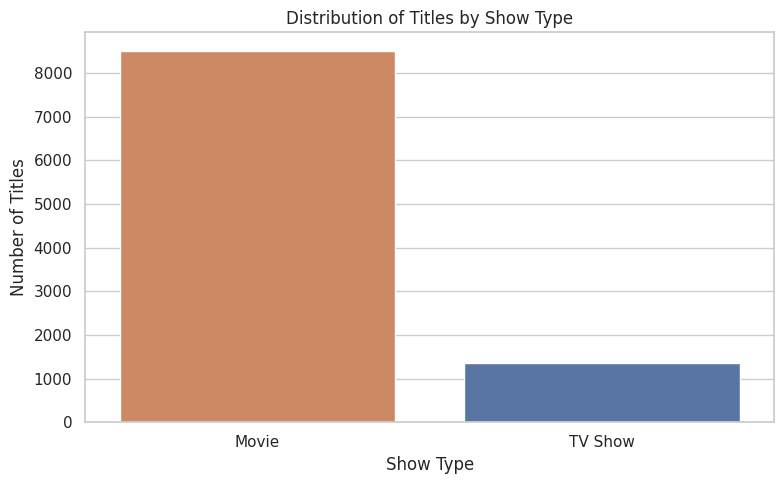

In [19]:
# 20. Visualization 1 — Movies vs TV Shows
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="show_type",
    hue="show_type",
    legend=False,
    order=df["show_type"].value_counts().index
)
plt.title("Distribution of Titles by Show Type")
plt.xlabel("Show Type")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

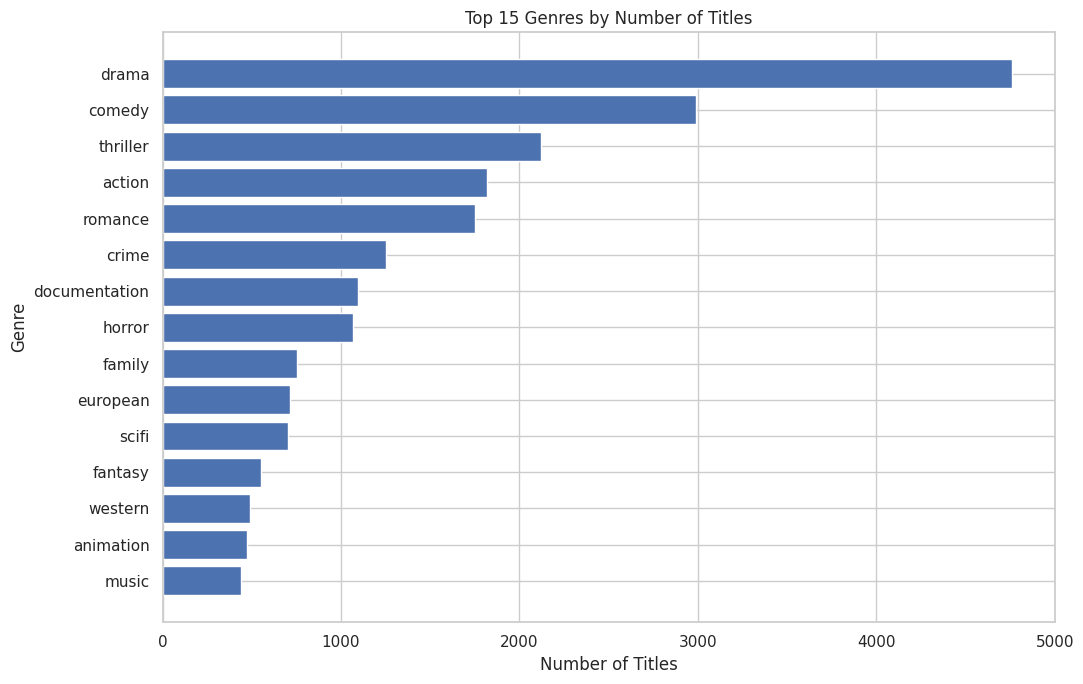

In [20]:
# 21. Visualization 2 — Top 15 Genres
top_genres = genre_summary.head(15).sort_values("title_count")

plt.figure(figsize=(11, 7))
plt.barh(top_genres.index, top_genres["title_count"])
plt.title("Top 15 Genres by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

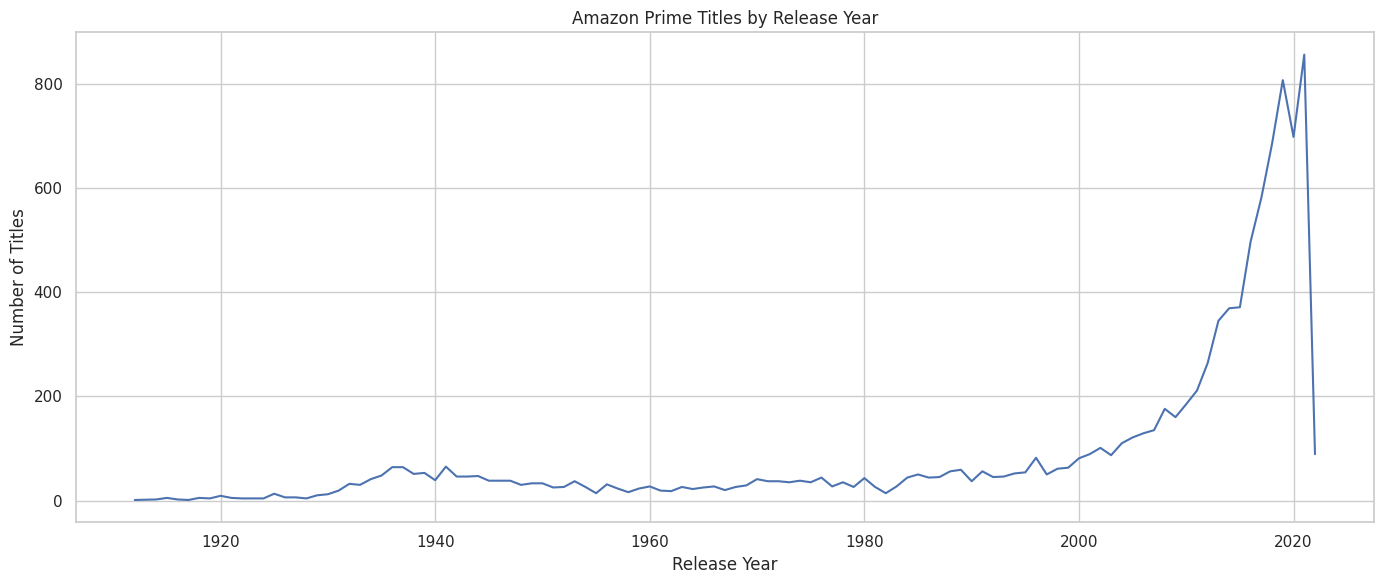

In [21]:
# 22. Visualization 3 — Titles by Release Year
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=year_summary,
    x="release_year",
    y="title_count"
)
plt.title("Amazon Prime Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

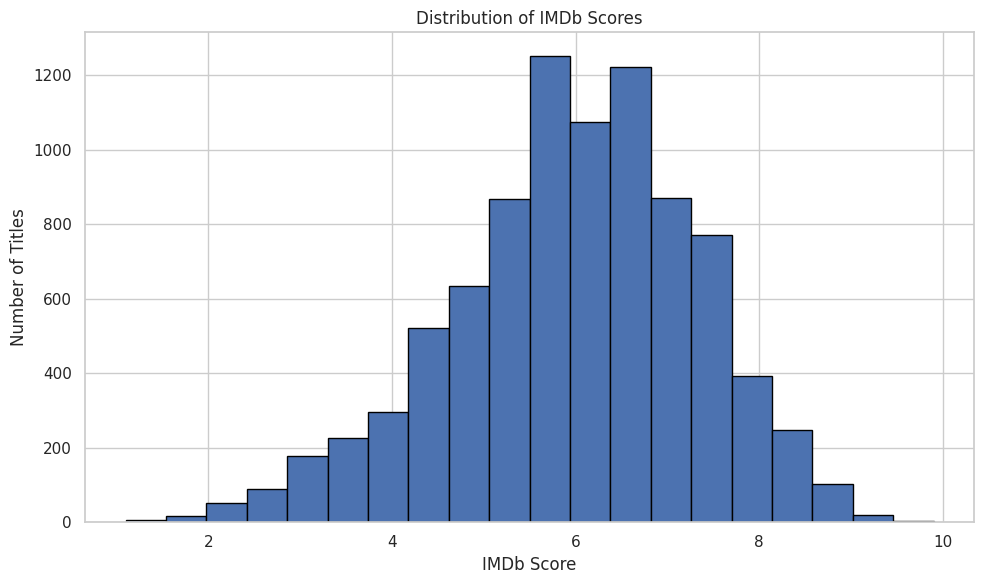

In [22]:
# 23. Visualization 4 — IMDb Score Distribution
plot_df = df.dropna(subset=["imdb_score"])
plt.figure(figsize=(10, 6))
plt.hist(plot_df["imdb_score"], bins=20, edgecolor="black")
plt.title("Distribution of IMDb Scores")
plt.xlabel("IMDb Score")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

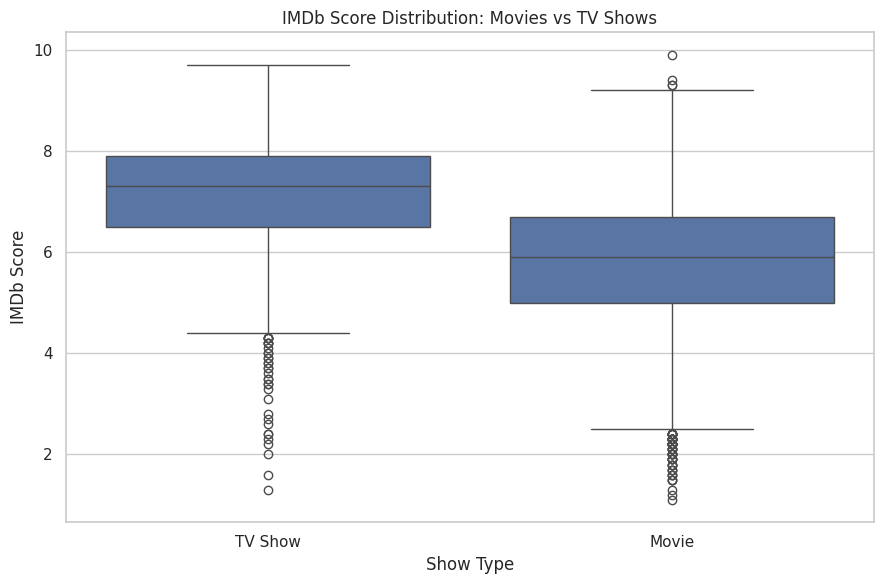

In [23]:
# 24. Visualization 5 — IMDb Score by Show Type
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="show_type",
    y="imdb_score"
)
plt.title("IMDb Score Distribution: Movies vs TV Shows")
plt.xlabel("Show Type")
plt.ylabel("IMDb Score")
plt.tight_layout()
plt.show()

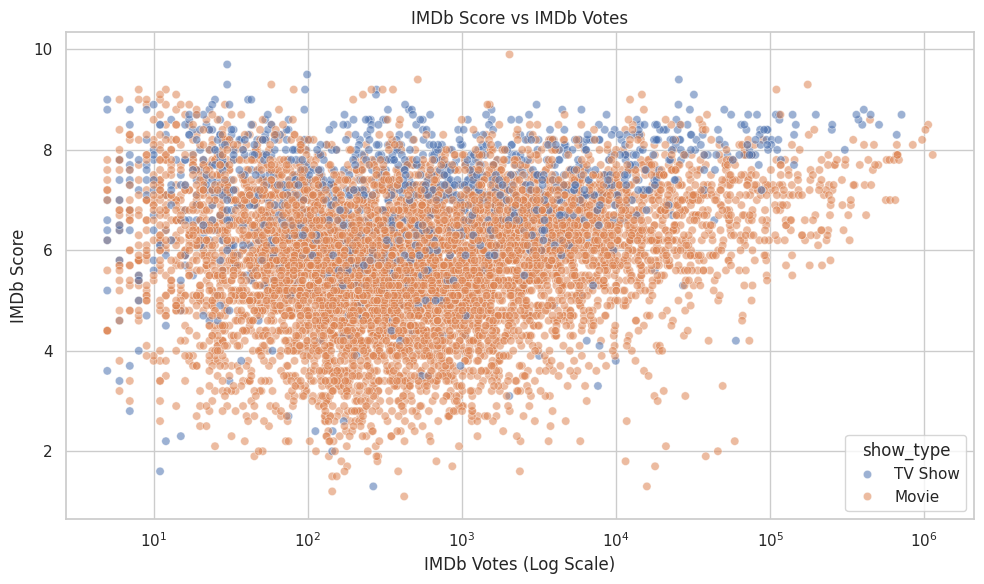

In [24]:
# 25. Visualization 6 — IMDb Score vs IMDb Votes
scatter_df = df.dropna(subset=["imdb_score", "imdb_votes"]).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_df,
    x="imdb_votes",
    y="imdb_score",
    hue="show_type",
    alpha=0.55
)
plt.xscale("log")
plt.title("IMDb Score vs IMDb Votes")
plt.xlabel("IMDb Votes (Log Scale)")
plt.ylabel("IMDb Score")
plt.tight_layout()
plt.show()

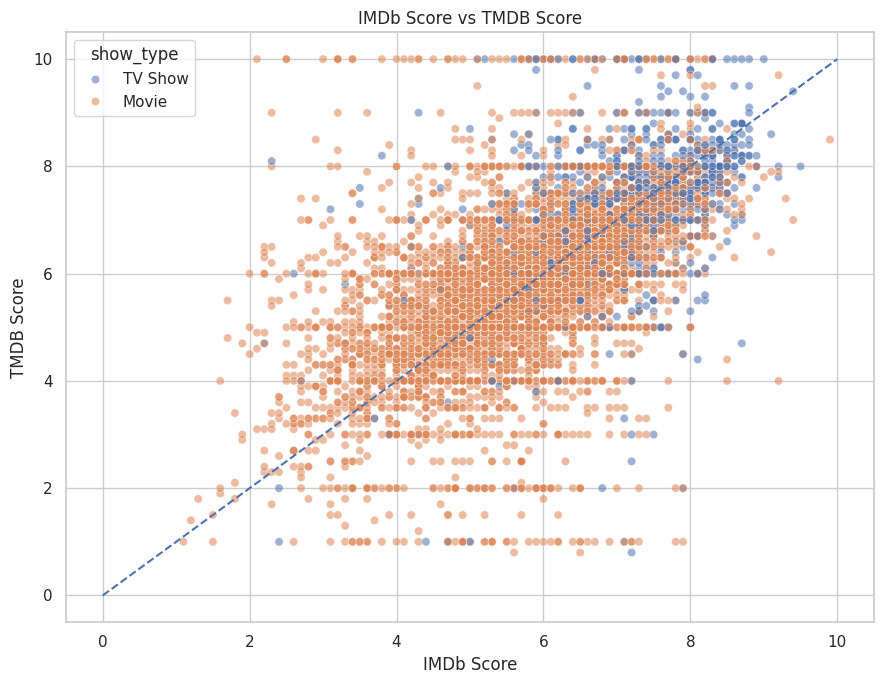

In [25]:
# 26. Visualization 7 — IMDb Score vs TMDB Score
score_df = df.dropna(subset=["imdb_score", "tmdb_score"]).copy()

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=score_df,
    x="imdb_score",
    y="tmdb_score",
    hue="show_type",
    alpha=0.55
)

# Reference line: equal IMDb and TMDB score
plt.plot([0, 10], [0, 10], linestyle="--")
plt.title("IMDb Score vs TMDB Score")
plt.xlabel("IMDb Score")
plt.ylabel("TMDB Score")
plt.tight_layout()
plt.show()

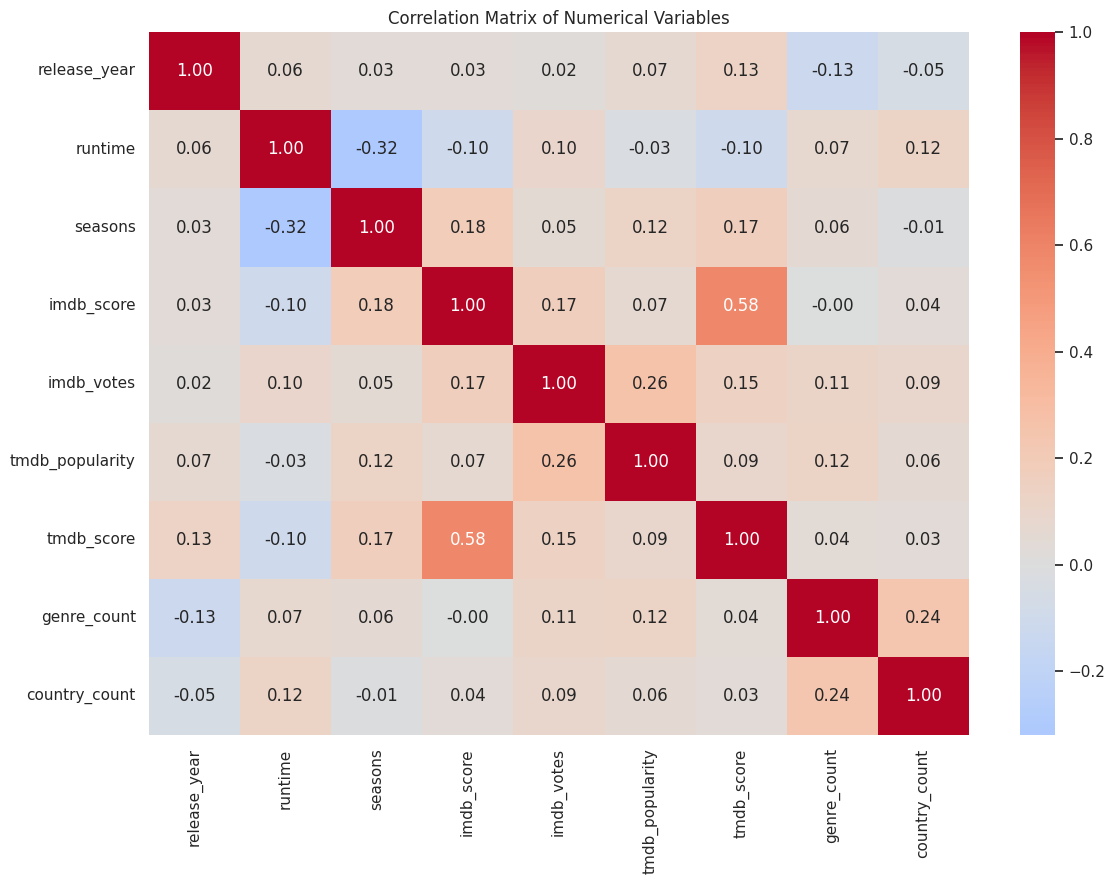

In [26]:
# 27. Visualization 8 — Numerical Correlation Heatmap
heatmap_cols = [
    "release_year", "runtime", "seasons",
    "imdb_score", "imdb_votes",
    "tmdb_popularity", "tmdb_score",
    "genre_count", "country_count"
]

plt.figure(figsize=(12, 9))
sns.heatmap(
    df[heatmap_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

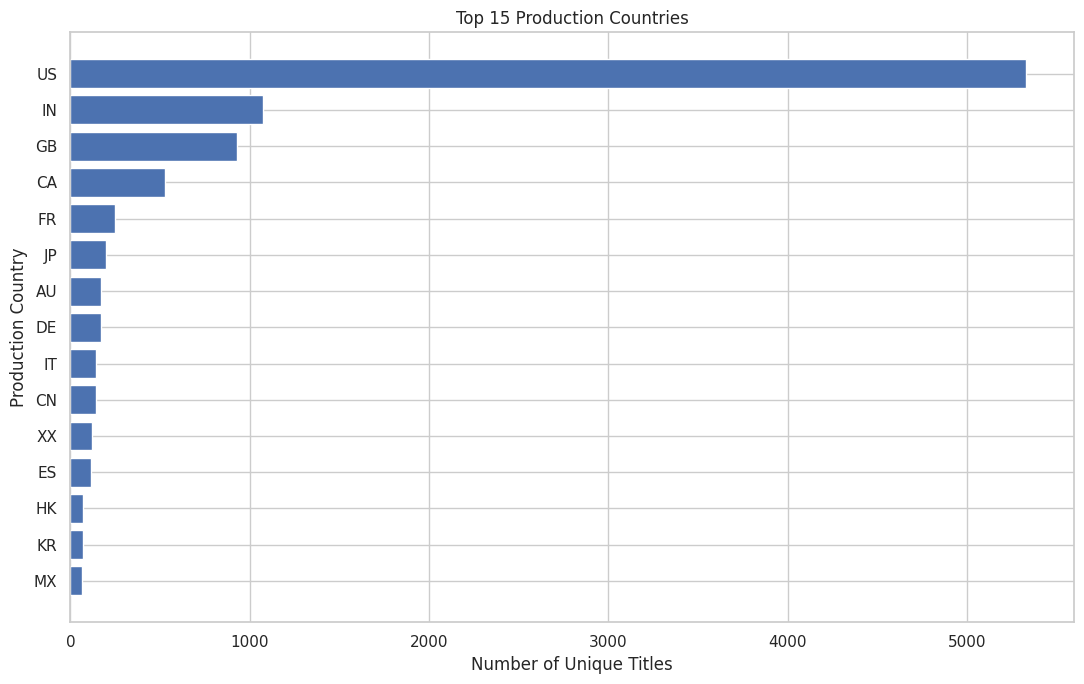

Insight: US is the leading production country in the supplied catalog, with 5,331 associated titles.


In [27]:
# 29. Visualization 9 — Top 15 Production Countries
country_plot = country_summary.head(15).sort_values("title_count")
plt.figure(figsize=(11, 7))
plt.barh(country_plot.index, country_plot["title_count"])
plt.title("Top 15 Production Countries")
plt.xlabel("Number of Unique Titles")
plt.ylabel("Production Country")
plt.tight_layout()
plt.show()
print(f"Insight: {country_summary.index[0]} is the leading production country in the supplied catalog, with {int(country_summary.iloc[0]['title_count']):,} associated titles.")

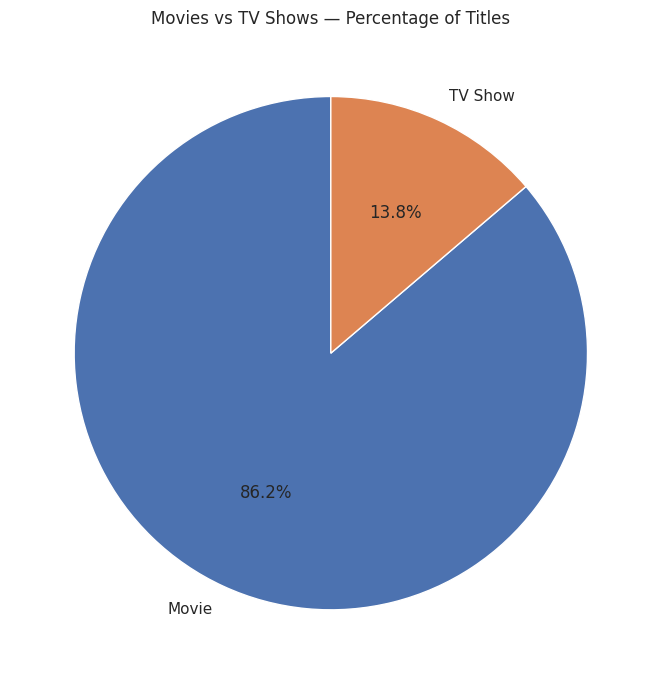

Insight: Movie: 86.2%, TV Show: 13.8%


In [28]:
# 30. Visualization 10 — Movies vs TV Shows Percentage
show_type_pct = df["show_type"].value_counts(normalize=True).mul(100)
plt.figure(figsize=(7, 7))
plt.pie(show_type_pct.values, labels=show_type_pct.index, autopct="%1.1f%%", startangle=90)
plt.title("Movies vs TV Shows — Percentage of Titles")
plt.tight_layout()
plt.show()
print("Insight: " + ", ".join([f"{k}: {v:.1f}%" for k, v in show_type_pct.items()]))

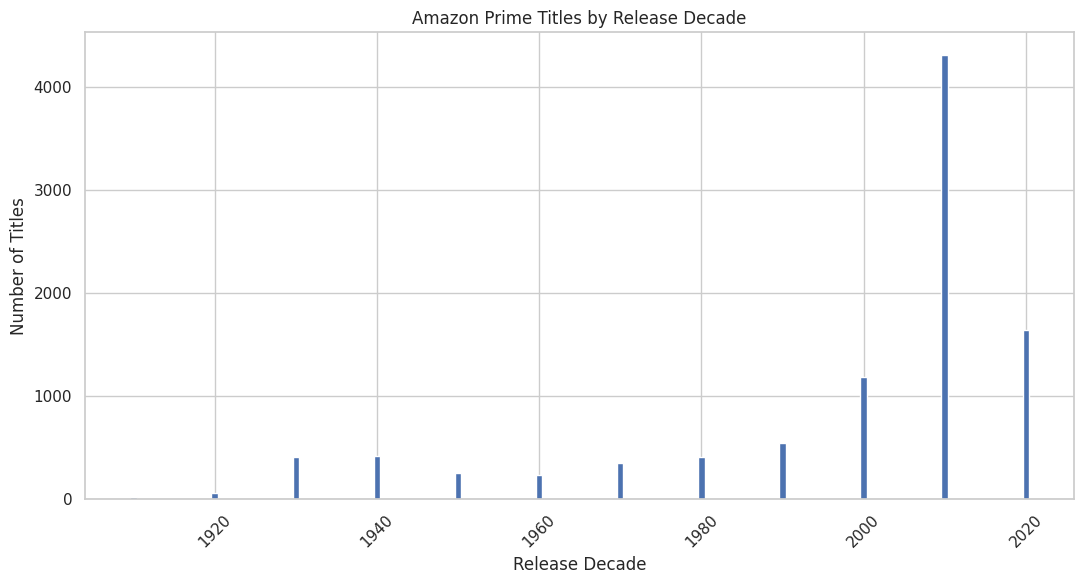

Insight: The 2010s contain the largest number of titles in the supplied dataset (4,315).


In [29]:
# 31. Visualization 11 — Titles by Release Decade
decade_summary = (df.dropna(subset=["release_decade"]).groupby("release_decade").agg(title_count=("id", "nunique")).sort_index())
plt.figure(figsize=(11, 6))
plt.bar(decade_summary.index.astype(int), decade_summary["title_count"].values)
plt.title("Amazon Prime Titles by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
peak_decade = int(decade_summary["title_count"].idxmax())
print(f"Insight: The {peak_decade}s contain the largest number of titles in the supplied dataset ({int(decade_summary.loc[peak_decade, 'title_count']):,}).")

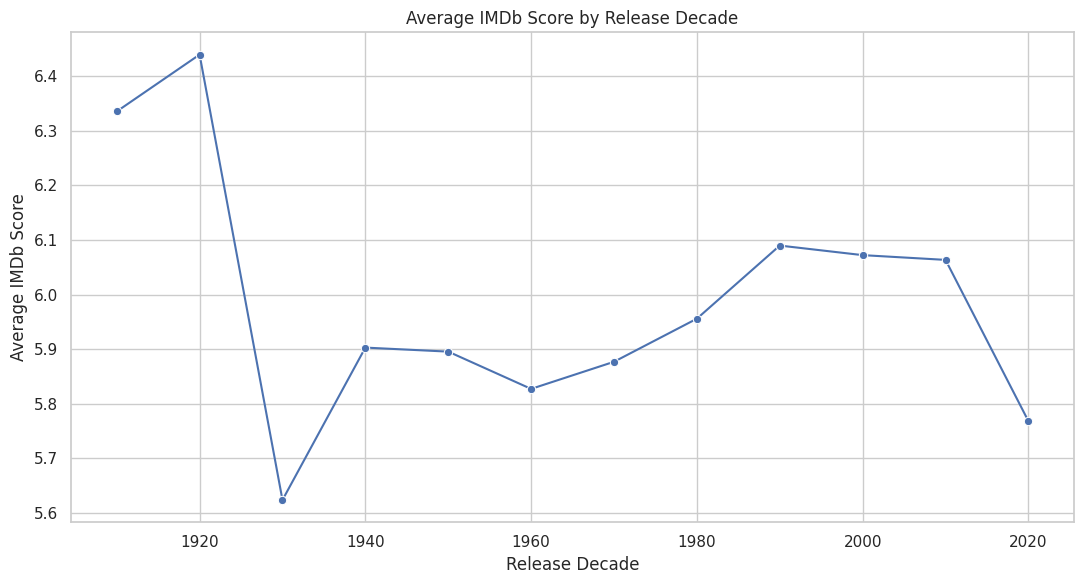

Insight: The 1920s have the highest average IMDb score among decades with available ratings (6.44).


In [30]:
# 32. Visualization 12 — Average IMDb Score by Release Decade
decade_rating = (df.dropna(subset=["release_decade", "imdb_score"]).groupby("release_decade")["imdb_score"].mean().sort_index())
plt.figure(figsize=(11, 6))
sns.lineplot(x=decade_rating.index.astype(int), y=decade_rating.values, marker="o")
plt.title("Average IMDb Score by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Average IMDb Score")
plt.tight_layout()
plt.show()
best_decade = int(decade_rating.idxmax())
print(f"Insight: The {best_decade}s have the highest average IMDb score among decades with available ratings ({decade_rating.loc[best_decade]:.2f}).")

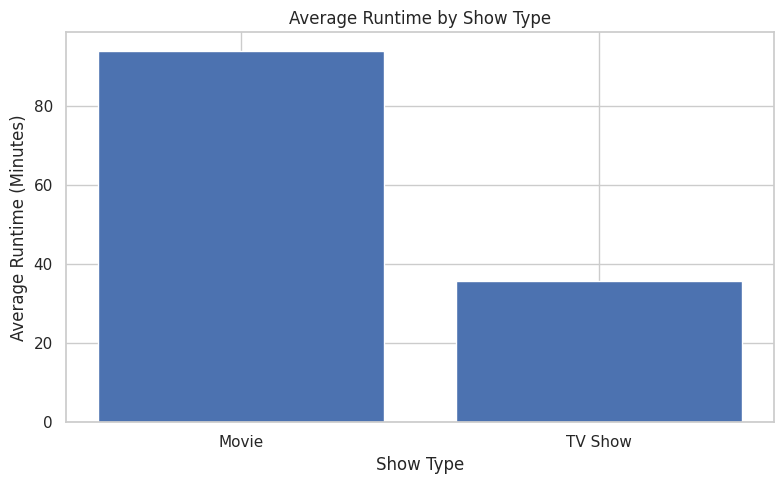

Insight: Movie: 94.0 minutes, TV Show: 35.8 minutes


In [31]:
# 33. Visualization 13 — Average Runtime by Show Type
runtime_type = df.dropna(subset=["runtime"]).groupby("show_type")["runtime"].mean()
plt.figure(figsize=(8, 5))
plt.bar(runtime_type.index, runtime_type.values)
plt.title("Average Runtime by Show Type")
plt.xlabel("Show Type")
plt.ylabel("Average Runtime (Minutes)")
plt.tight_layout()
plt.show()
print("Insight: " + ", ".join([f"{k}: {v:.1f} minutes" for k, v in runtime_type.items()]))

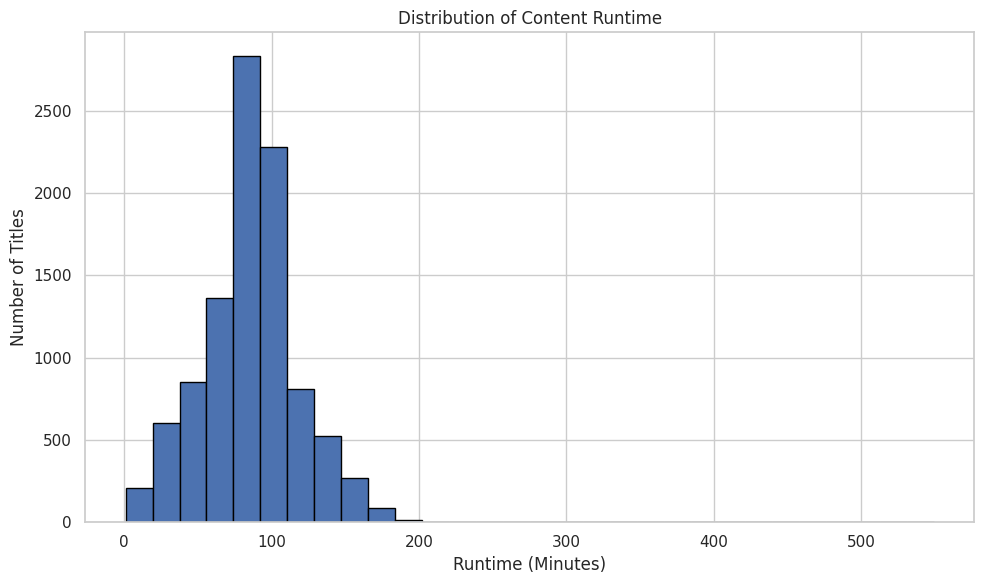

Insight: The median runtime is 89.0 minutes, while the mean runtime is 86.0 minutes.


In [32]:
# 34. Visualization 14 — Runtime Distribution
runtime_df = df.dropna(subset=["runtime"])
plt.figure(figsize=(10, 6))
plt.hist(runtime_df["runtime"], bins=30, edgecolor="black")
plt.title("Distribution of Content Runtime")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()
print(f"Insight: The median runtime is {runtime_df['runtime'].median():.1f} minutes, while the mean runtime is {runtime_df['runtime'].mean():.1f} minutes.")

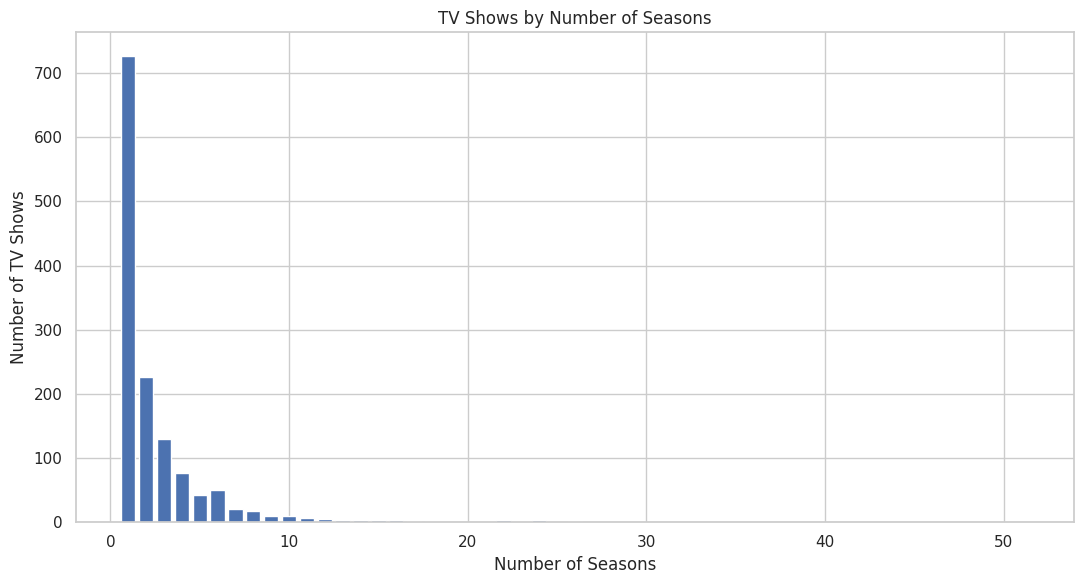

Insight: 1 season(s) is the most common season count among TV shows with recorded seasons.


In [33]:
# 35. Visualization 15 — TV Shows by Number of Seasons
tv_seasons = df[(df["show_type"] == "TV Show") & (df["seasons"] > 0)]
season_count = tv_seasons["seasons"].value_counts().sort_index()
plt.figure(figsize=(11, 6))
plt.bar(season_count.index, season_count.values)
plt.title("TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.tight_layout()
plt.show()
common_seasons = int(season_count.idxmax())
print(f"Insight: {common_seasons} season(s) is the most common season count among TV shows with recorded seasons.")

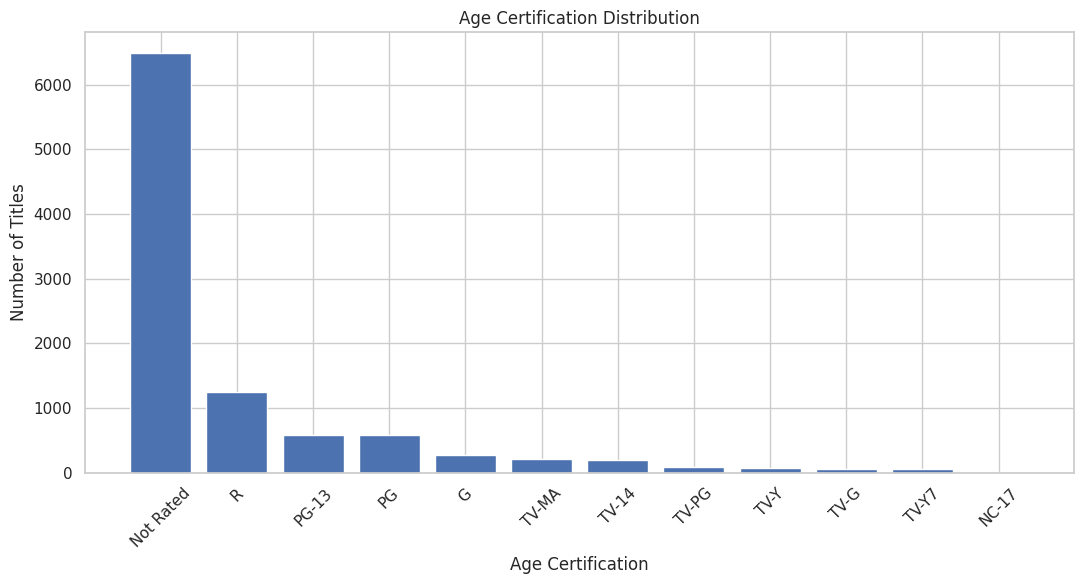

Insight: Not Rated is the most common age certification category (6,484 titles).


In [34]:
# 36. Visualization 16 — Age Certification Distribution
cert_count = df["age_certification"].fillna("Not Rated").value_counts()
plt.figure(figsize=(11, 6))
plt.bar(cert_count.index, cert_count.values)
plt.title("Age Certification Distribution")
plt.xlabel("Age Certification")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"Insight: {cert_count.index[0]} is the most common age certification category ({int(cert_count.iloc[0]):,} titles).")

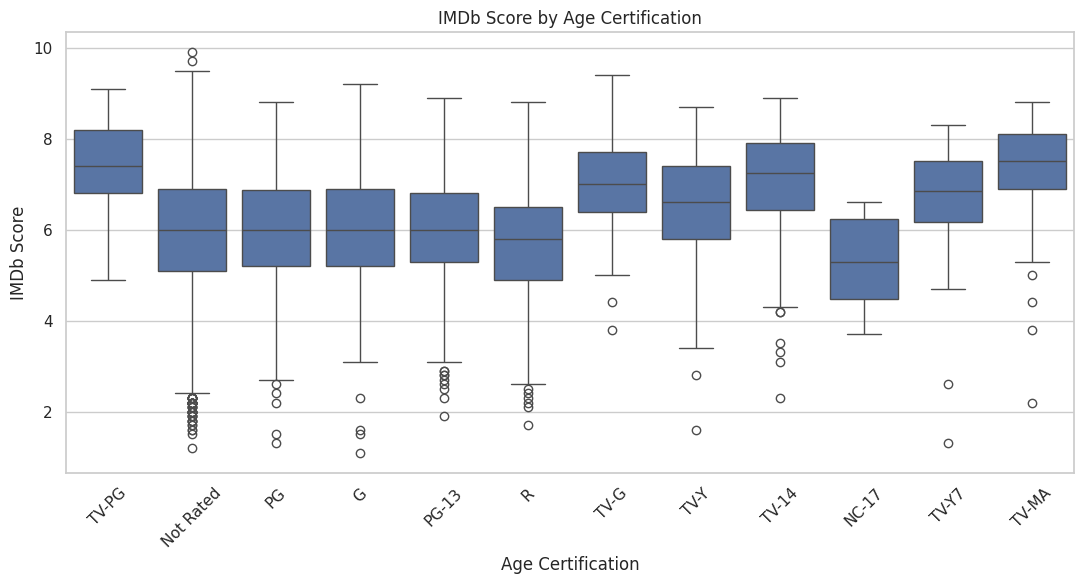

Insight: TV-MA has the highest median IMDb score among certification groups with available ratings (7.50).


In [35]:
# 37. Visualization 17 — IMDb Score by Age Certification
cert_rating_df = df.dropna(subset=["imdb_score"]).copy()
plt.figure(figsize=(11, 6))
sns.boxplot(data=cert_rating_df, x="age_certification", y="imdb_score")
plt.title("IMDb Score by Age Certification")
plt.xlabel("Age Certification")
plt.ylabel("IMDb Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
cert_medians = cert_rating_df.groupby("age_certification")["imdb_score"].median().sort_values(ascending=False)
print(f"Insight: {cert_medians.index[0]} has the highest median IMDb score among certification groups with available ratings ({cert_medians.iloc[0]:.2f}).")

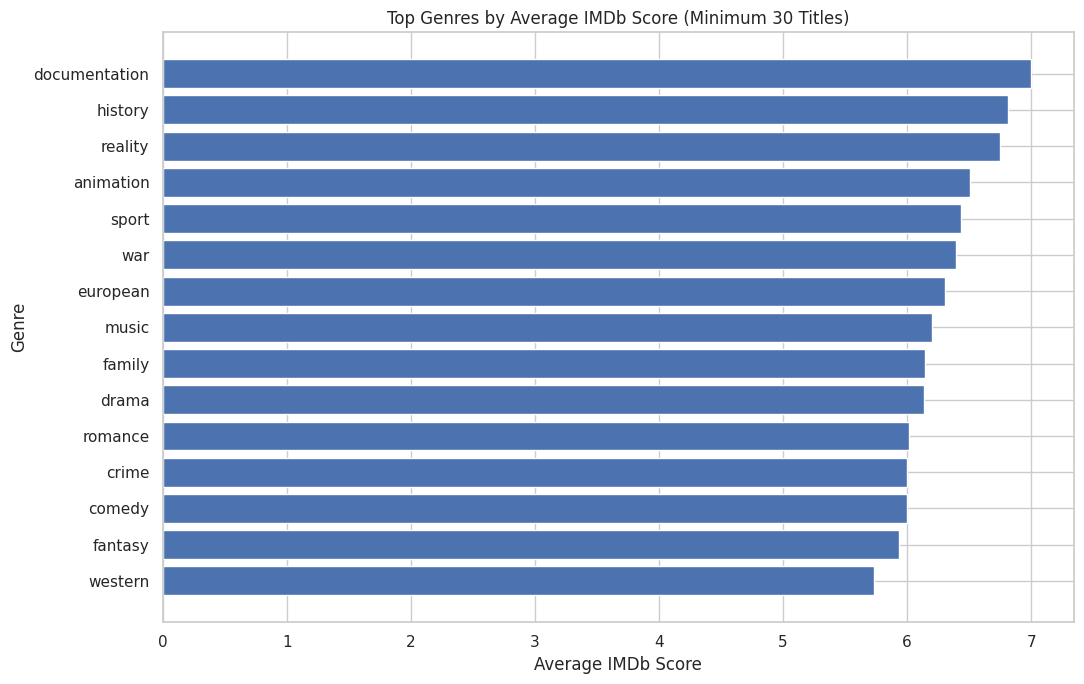

Insight: documentation has the highest average IMDb score among genres meeting the minimum sample-size threshold (6.99).


In [36]:
# 38. Visualization 18 — Top Genres by Average IMDb Score
genre_performance_viz = (
    genre_long[genre_long["genres"].ne("")]
    .groupby("genres")
    .agg(
        title_count=("id", "nunique"),
        average_imdb=("imdb_score", "mean")
    )
    .query("title_count >= 30")
    .sort_values("average_imdb", ascending=False)
)
genre_rating_plot = genre_performance_viz.head(15).sort_values("average_imdb")

plt.figure(figsize=(11, 7))
plt.barh(genre_rating_plot.index, genre_rating_plot["average_imdb"])
plt.title("Top Genres by Average IMDb Score (Minimum 30 Titles)")
plt.xlabel("Average IMDb Score")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

best_genre_viz = genre_performance_viz.index[0]
best_genre_score_viz = genre_performance_viz.iloc[0]["average_imdb"]
print(f"Insight: {best_genre_viz} has the highest average IMDb score among genres meeting the minimum sample-size threshold ({best_genre_score_viz:.2f}).")

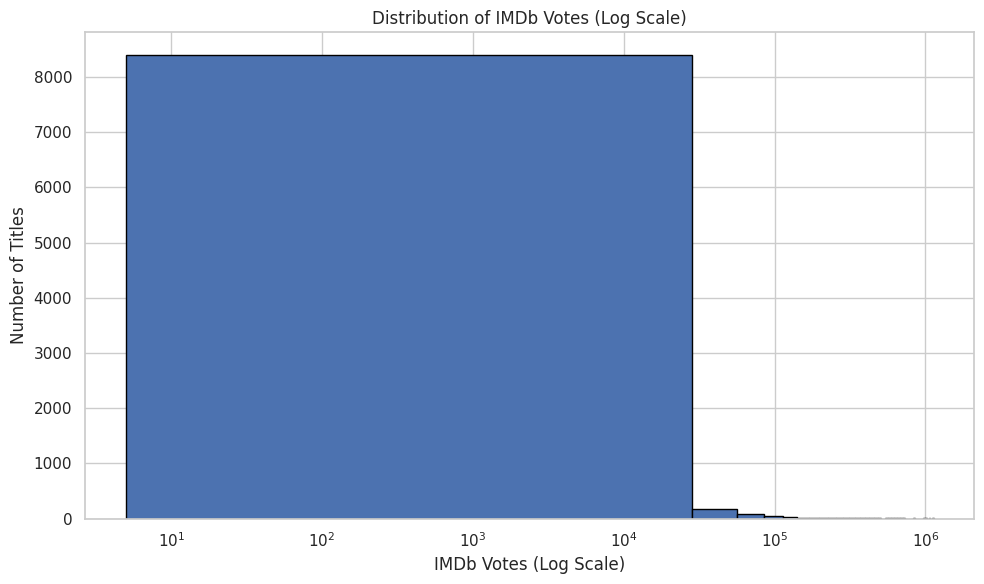

Insight: IMDb vote counts are highly dispersed; the median is 464 votes, compared with a mean of 8,536.


In [37]:
# 39. Visualization 19 — IMDb Votes Distribution
votes_df = df.dropna(subset=["imdb_votes"])
plt.figure(figsize=(10, 6))
plt.hist(votes_df["imdb_votes"], bins=40, edgecolor="black")
plt.xscale("log")
plt.title("Distribution of IMDb Votes (Log Scale)")
plt.xlabel("IMDb Votes (Log Scale)")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()
print(f"Insight: IMDb vote counts are highly dispersed; the median is {votes_df['imdb_votes'].median():,.0f} votes, compared with a mean of {votes_df['imdb_votes'].mean():,.0f}.")

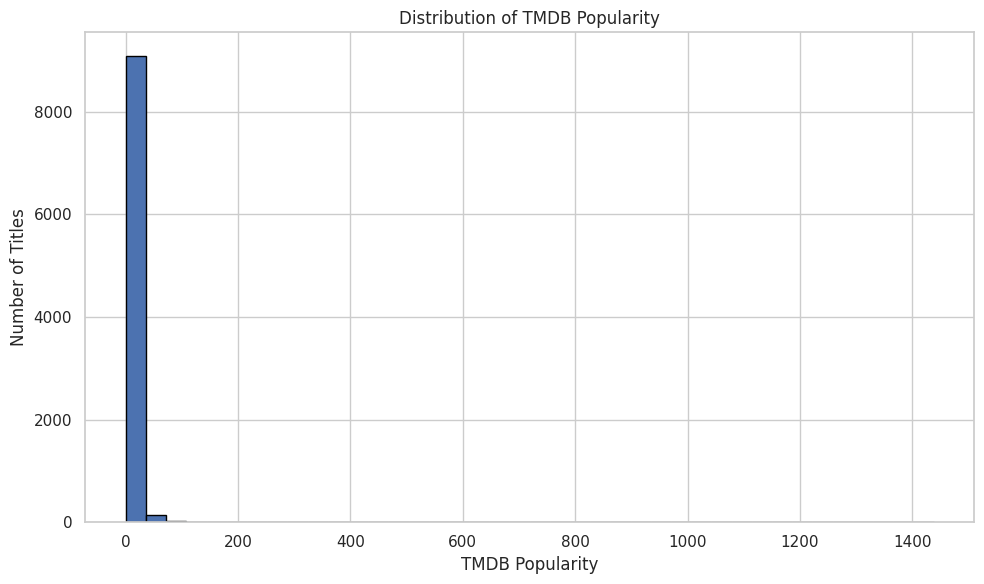

Insight: The median TMDB popularity is 2.54, while the mean is 6.91.


In [38]:
# 40. Visualization 20 — TMDB Popularity Distribution
popularity_df = df.dropna(subset=["tmdb_popularity"])
plt.figure(figsize=(10, 6))
plt.hist(popularity_df["tmdb_popularity"], bins=40, edgecolor="black")
plt.title("Distribution of TMDB Popularity")
plt.xlabel("TMDB Popularity")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()
print(f"Insight: The median TMDB popularity is {popularity_df['tmdb_popularity'].median():.2f}, while the mean is {popularity_df['tmdb_popularity'].mean():.2f}.")

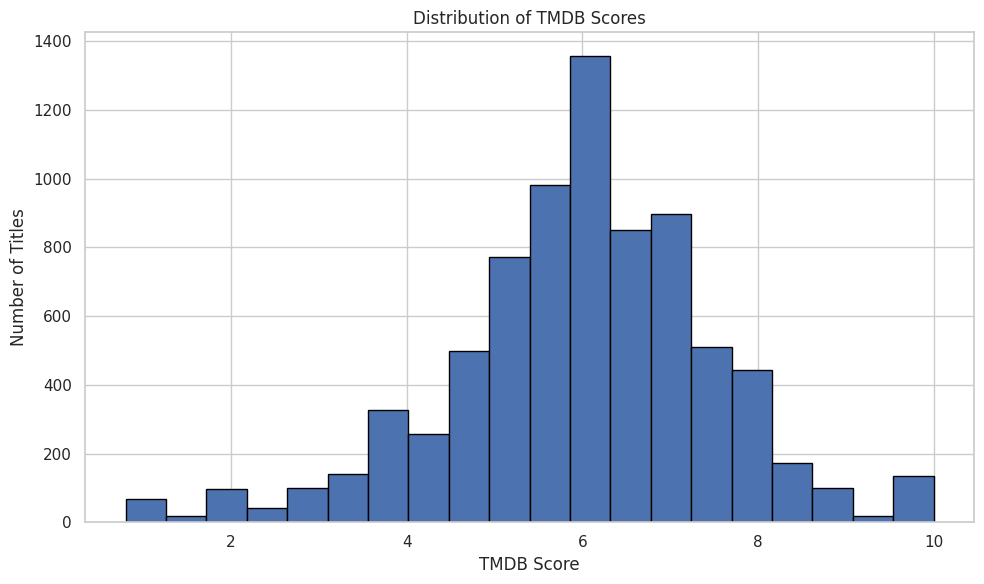

Insight: The average TMDB score is 5.98, with a median of 6.00.


In [39]:
# 41. Visualization 21 — TMDB Score Distribution
tmdb_score_df = df.dropna(subset=["tmdb_score"])
plt.figure(figsize=(10, 6))
plt.hist(tmdb_score_df["tmdb_score"], bins=20, edgecolor="black")
plt.title("Distribution of TMDB Scores")
plt.xlabel("TMDB Score")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()
print(f"Insight: The average TMDB score is {tmdb_score_df['tmdb_score'].mean():.2f}, with a median of {tmdb_score_df['tmdb_score'].median():.2f}.")

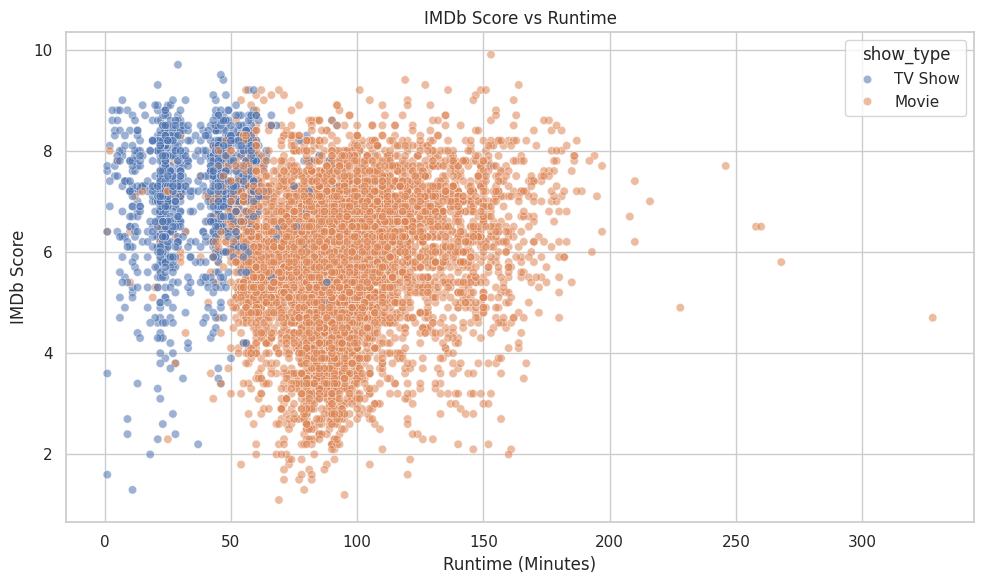

Insight: Runtime and IMDb score have a correlation of -0.10.


In [40]:
# 42. Visualization 22 — IMDb Score vs Runtime
score_runtime_df = df.dropna(subset=["imdb_score", "runtime"]).copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=score_runtime_df, x="runtime", y="imdb_score", hue="show_type", alpha=0.55)
plt.title("IMDb Score vs Runtime")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("IMDb Score")
plt.tight_layout()
plt.show()
score_runtime_corr = score_runtime_df["runtime"].corr(score_runtime_df["imdb_score"])
print(f"Insight: Runtime and IMDb score have a correlation of {score_runtime_corr:.2f}.")

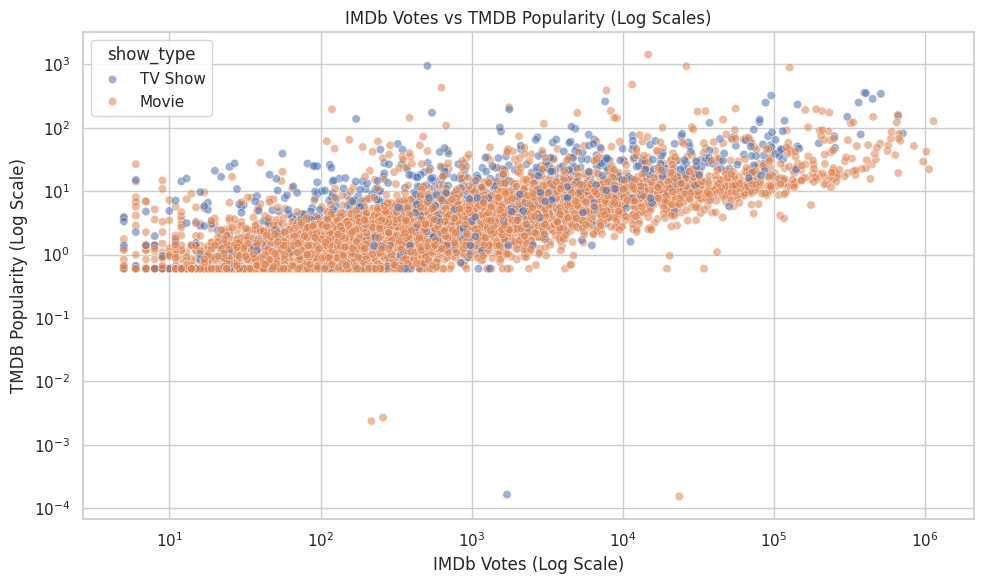

Insight: IMDb votes and TMDB popularity have a correlation of 0.26.


In [41]:
# 43. Visualization 23 — IMDb Votes vs TMDB Popularity
votes_pop_df = df.dropna(subset=["imdb_votes", "tmdb_popularity"]).copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=votes_pop_df, x="imdb_votes", y="tmdb_popularity", hue="show_type", alpha=0.55)
plt.xscale("log")
plt.yscale("log")
plt.title("IMDb Votes vs TMDB Popularity (Log Scales)")
plt.xlabel("IMDb Votes (Log Scale)")
plt.ylabel("TMDB Popularity (Log Scale)")
plt.tight_layout()
plt.show()
votes_pop_corr = votes_pop_df["imdb_votes"].corr(votes_pop_df["tmdb_popularity"])
print(f"Insight: IMDb votes and TMDB popularity have a correlation of {votes_pop_corr:.2f}.")

# 7. Additional Statistical Analysis

## Rating Quality Check

A high IMDb score with very few votes may be less reliable than a high score supported by many votes. Therefore, rating analysis should consider both `imdb_score` and `imdb_votes`.

We use a minimum-vote threshold rather than treating every rating equally.

In [42]:
# 28. Highly rated titles with sufficient IMDb votes
min_votes = 1000

high_rated = (
    df[
        (df["imdb_score"] >= 8) &
        (df["imdb_votes"] >= min_votes)
    ]
    .sort_values(
        ["imdb_score", "imdb_votes"],
        ascending=[False, False]
    )
)

display(
    high_rated[
        [
            "title", "show_type", "release_year",
            "imdb_score", "imdb_votes",
            "tmdb_score", "tmdb_popularity"
        ]
    ].head(20)
)

,title,show_type,release_year,imdb_score,imdb_votes,tmdb_score,tmdb_popularity
9135,Pawankhind,Movie,2022,9.9,2036.0,8.5,3.812
7422,The Chosen,TV Show,2019,9.4,25538.0,9.4,30.771
9052,Jai Bhim,Movie,2021,9.3,175187.0,7.4,6.051
7858,Soorarai Pottru,Movie,2020,9.2,109759.0,7.9,4.146
8978,Clarkson's Farm,TV Show,2021,9.1,31981.0,8.6,18.178
8156,Peranbu,Movie,2019,9.1,14708.0,7.9,2.508
9199,#Home,Movie,2021,9.0,12325.0,7.8,2.271
4577,Nathan For You,TV Show,2013,8.9,25396.0,8.0,10.796
7924,The Test: A New Era for Australia's Team,TV Show,2020,8.9,3050.0,7.6,1.982
9153,A Father's Fight,Movie,2021,8.9,1515.0,NaN,1.015


In [43]:
# 29. Genre performance with a minimum sample size
genre_performance = (
    genre_long.groupby("genres")
    .agg(
        title_count=("id", "nunique"),
        average_imdb=("imdb_score", "mean"),
        median_imdb=("imdb_score", "median")
    )
)

genre_performance = (
    genre_performance[
        genre_performance["title_count"] >= 30
    ]
    .sort_values("average_imdb", ascending=False)
)

display(genre_performance.head(15).round(2))

,title_count,average_imdb,median_imdb
genres,,,
documentation,1096,6.99,7.1
history,396,6.81,6.9
reality,138,6.75,7.0
animation,475,6.51,6.6
sport,228,6.44,6.5
war,324,6.40,6.5
european,712,6.31,6.4
music,438,6.20,6.2
family,751,6.15,6.2


In [44]:
# 30. Movie vs TV Show statistical comparison
type_stats = (
    df.groupby("show_type")
      .agg(
          titles=("id", "nunique"),
          avg_imdb=("imdb_score", "mean"),
          median_imdb=("imdb_score", "median"),
          avg_runtime=("runtime", "mean"),
          avg_votes=("imdb_votes", "mean"),
          avg_popularity=("tmdb_popularity", "mean")
      )
      .round(2)
)

display(type_stats)

,titles,avg_imdb,median_imdb,avg_runtime,avg_votes,avg_popularity
show_type,,,,,,
Movie,8511,5.80,5.9,93.98,8278.77,5.76
TV Show,1357,7.12,7.3,35.80,10235.33,14.51


# 8. Actor & Director Analysis

Credits are analyzed separately because one title can have multiple people.

The metric used is **number of unique titles**, not number of rows.

In [45]:
# 31. Top actors by number of unique titles
actors = credits_df[credits_df["role"] == "ACTOR"].copy()

top_actors = (
    actors.groupby("name")["id"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

display(top_actors.to_frame("unique_titles"))

,unique_titles
name,
George 'Gabby' Hayes,49
Roy Rogers,45
Bess Flowers,44
Gene Autry,40
Nassar,37
Herman Hack,35
Earl Dwire,34
George Morrell,34
Forrest Taylor,34


In [46]:
# 32. Top directors by number of unique titles
directors = credits_df[credits_df["role"] == "DIRECTOR"].copy()

top_directors = (
    directors.groupby("name")["id"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

display(top_directors.to_frame("unique_titles"))

,unique_titles
name,
Joseph Kane,41
Sam Newfield,38
Jay Chapman,34
Lesley Selander,22
Harry L. Fraser,21
John English,21
William Nigh,20
Robert N. Bradbury,17
Manny Rodriguez,17


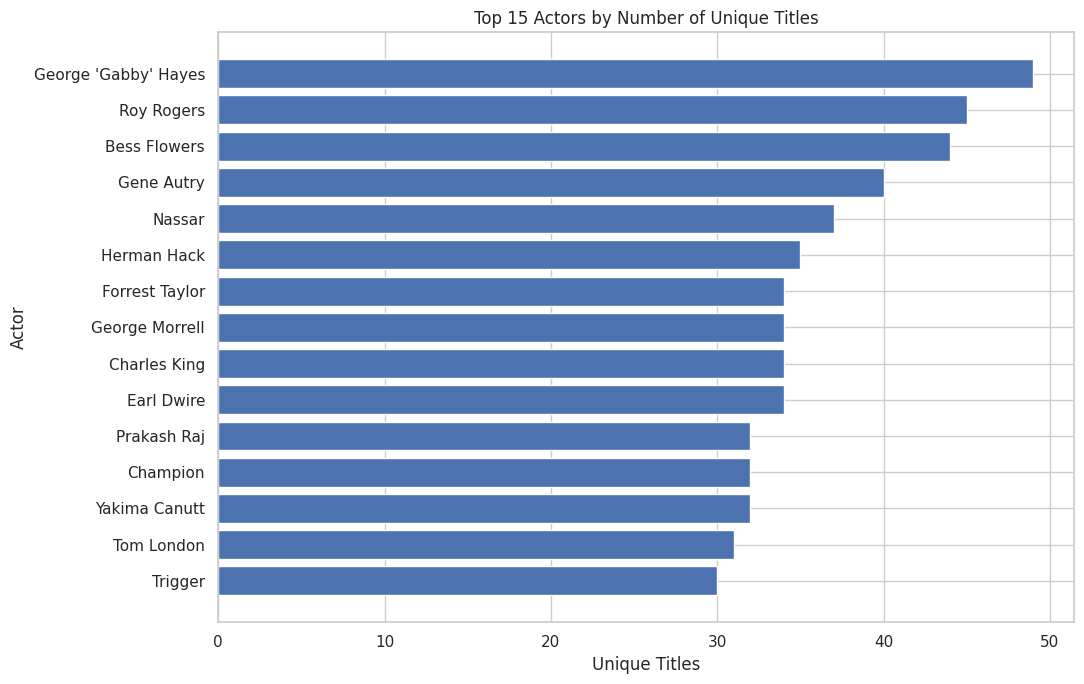

In [47]:
# 44. Visualization 24 — Top 15 Actors
actor_plot = (
    top_actors.head(15)
    .sort_values()
    .reset_index()
)
actor_plot.columns = ["name", "title_count"]

plt.figure(figsize=(11, 7))
plt.barh(actor_plot["name"], actor_plot["title_count"])
plt.title("Top 15 Actors by Number of Unique Titles")
plt.xlabel("Unique Titles")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()

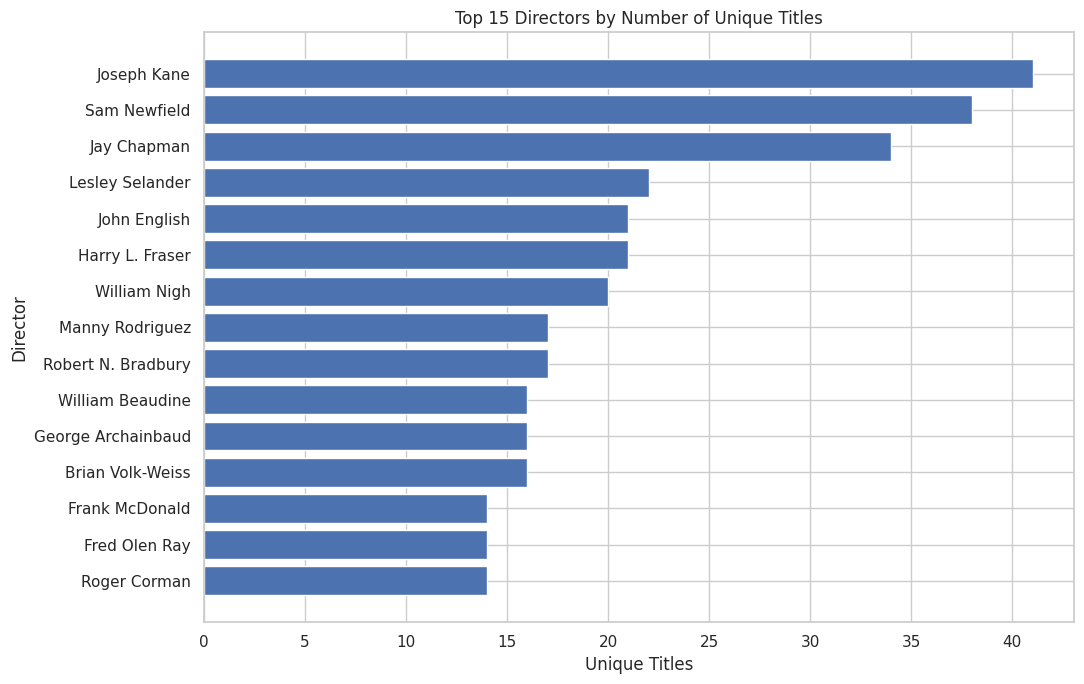

In [48]:
# 45. Visualization 25 — Top 15 Directors
director_plot = (
    top_directors.head(15)
    .sort_values()
    .reset_index()
)
director_plot.columns = ["name", "title_count"]

plt.figure(figsize=(11, 7))
plt.barh(director_plot["name"], director_plot["title_count"])
plt.title("Top 15 Directors by Number of Unique Titles")
plt.xlabel("Unique Titles")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

# 9. Data-Backed Insights

The following section calculates the key findings directly from the dataset rather than hard-coding assumptions.

### Questions from the project flow

- Are Movies more dominant than TV Shows?
- Are genres such as Drama or Action common?
- Which production countries contribute the most titles?
- Which year had the highest number of released titles?
- What is the relationship between IMDb and TMDB scores?
- Which talent appears across many titles?

In [49]:
# 46. Generate data-backed insights
movie_count = int((df["show_type"] == "Movie").sum())
tv_count = int((df["show_type"] == "TV Show").sum())
total_titles = movie_count + tv_count

movie_pct = movie_count / total_titles * 100
tv_pct = tv_count / total_titles * 100

dominant_type = "Movies" if movie_count > tv_count else "TV Shows"

top_genre = genre_summary.index[0]
top_genre_count = int(genre_summary.iloc[0]["title_count"])

top_country = country_summary.index[0]
top_country_count = int(country_summary.iloc[0]["title_count"])

peak_year_row = year_summary.loc[year_summary["title_count"].idxmax()]
peak_year = int(peak_year_row["release_year"])
peak_year_count = int(peak_year_row["title_count"])

imdb_tmdb_corr = df["imdb_score"].corr(df["tmdb_score"])
imdb_votes_corr = df["imdb_score"].corr(df["imdb_votes"])

best_genre = genre_performance.index[0]
best_genre_score = genre_performance.iloc[0]["average_imdb"]

print("KEY INSIGHTS")
print("-" * 70)

print(
    f"1. Content mix: {dominant_type} dominate the library with "
    f"{movie_pct:.1f}% Movies and {tv_pct:.1f}% TV Shows."
)

print(
    f"2. Genre concentration: '{top_genre}' is the most common genre, "
    f"appearing in {top_genre_count:,} unique titles."
)

print(
    f"3. Production footprint: '{top_country}' is the leading production country, "
    f"associated with {top_country_count:,} unique titles."
)

print(
    f"4. Release trend: {peak_year} has the highest number of titles in the dataset, "
    f"with {peak_year_count:,} titles."
)

print(
    f"5. Ratings relationship: IMDb and TMDB scores have a correlation of "
    f"{imdb_tmdb_corr:.2f}."
)

print(
    f"6. Votes relationship: IMDb score and IMDb votes have a correlation of "
    f"{imdb_votes_corr:.2f}; therefore, vote volume should be considered separately "
    f"from rating quality."
)

print(
    f"7. Genre performance: among genres with at least 30 titles, "
    f"'{best_genre}' has the highest average IMDb score ({best_genre_score:.2f})."
)

KEY INSIGHTS
----------------------------------------------------------------------
1. Content mix: Movies dominate the library with 86.2% Movies and 13.8% TV Shows.
2. Genre concentration: 'drama' is the most common genre, appearing in 4,762 unique titles.
3. Production footprint: 'US' is the leading production country, associated with 5,331 unique titles.
4. Release trend: 2021 has the highest number of titles in the dataset, with 856 titles.
5. Ratings relationship: IMDb and TMDB scores have a correlation of 0.58.
6. Votes relationship: IMDb score and IMDb votes have a correlation of 0.17; therefore, vote volume should be considered separately from rating quality.
7. Genre performance: among genres with at least 30 titles, 'documentation' has the highest average IMDb score (6.99).


# 10. Business Recommendations

## Content Strategists
- Use the movie/TV-show mix to understand the platform's current content structure.
- Monitor high-volume genres while also evaluating high-rated genres.
- Use release-year trends to understand periods of stronger content production.
- Consider production-country patterns when planning regional content investment.

## Marketing Teams
- Promote highly rated titles that also have meaningful IMDb vote volume.
- Use popular genres for broad campaigns.
- Segment campaigns by content type, genre, and age certification.

## Investors / Business Stakeholders
- Track changes in content production volume over time.
- Compare ratings with popularity rather than relying on one metric.
- Examine geographic production concentration and diversification.
- Use actor/director participation as supporting information for content strategy.

# 11. Important Data Interpretation Notes

1. `production_countries` represents countries associated with production; it should not automatically be interpreted as geographic availability.
2. `credits.csv` contains multiple rows per title, so title counts after merging must use `nunique()`.
3. Missing `seasons` is expected for Movies.
4. IMDb score alone can be misleading for titles with very few votes; use `imdb_votes` as supporting context.
5. A title can belong to multiple genres, so genre counts can exceed the total number of titles.
6. Correlation measures association, not causation.
7. The dataset describes the supplied Amazon Prime Video catalog; the analysis does not establish viewer behavior or subscription impact.

# 12. Final Conclusion

This EDA project analyzes Amazon Prime Video's content library using **Python, Pandas, NumPy, Matplotlib, Seaborn, and Google Colab**.

The project covers:

- Project statement and business questions
- Dataset understanding
- Missing-value and duplicate analysis
- Data cleaning and feature engineering
- Titles and credits integration
- Content mix and genre analysis
- Production-country analysis
- Release-year trends
- IMDb/TMDB ratings and popularity
- Actor and director participation
- 25 Matplotlib/Seaborn visualizations
- Statistical summaries and correlations
- Data-backed insights
- Business recommendations

The main objective is to convert raw streaming data into practical information that can support **content strategy, marketing decisions, and business investment discussions**.



## Submission Links

**GitHub Repository:** Paste your accessible GitHub URL here.

**Google Colab Notebook:   https://colab.research.google.com/drive/17mEUZpMyH4uDNNvgZeodswffwni710cl?usp=sharing


